In [1]:
import pandas as pd
import numpy as np
#Load the data
df = pd.read_csv('quikr_car.csv')
df.head()

,name,company,year,Price,kms_driven,fuel_type
0,Hyundai Santro Xing XO eRLX Euro III,Hyundai,2007,"80,000","45,000 kms",Petrol
1,Mahindra Jeep CL550 MDI,Mahindra,2006,"4,25,000",40 kms,Diesel
2,Maruti Suzuki Alto 800 Vxi,Maruti,2018,Ask For Price,"22,000 kms",Petrol
3,Hyundai Grand i10 Magna 1.2 Kappa VTVT,Hyundai,2014,"3,25,000","28,000 kms",Petrol
4,Ford EcoSport Titanium 1.5L TDCi,Ford,2014,"5,75,000","36,000 kms",Diesel


In [2]:
#CHeck initial Status
print("Initial missing values:")
print(df.isnull().sum())

Initial missing values:
name           0
company        0
year           0
Price          0
kms_driven    52
fuel_type     55
dtype: int64


In [3]:
#1. Clean 'kms_driven'
#Remove 'kms' and ',' then convert to numeric
df['kms_driven'] = df['kms_driven'].str.replace('kms','').str.replace(',','')
df['kms_driven'] = pd.to_numeric(df['kms_driven'], errors='coerce')
df['kms_driven'] = df['kms_driven'].fillna(df['kms_driven'].median())

In [5]:
#2. Clean 'Price'
#Remove 'Ask for price' rows first
df = df[df['Price'] != 'Ask For Price']
#Remove commas and convert to integer
df['Price'] = df['Price'].str.replace(',','').astype(int)

In [6]:
#3. Clean 'fuel_type'
#Fill missing with the most frequent fuel type (mode)
df['fuel_type'] = df['fuel_type'].fillna(df['fuel_type'].mode()[0])

In [7]:
#Final check
print("Is the data clean?")
print(df.isnull().sum())

Is the data clean?
name          0
company       0
year          0
Price         0
kms_driven    0
fuel_type     0
dtype: int64


In [8]:
#Q1: Average Price by Fuel Type
print(df.groupby('fuel_type')['Price'].mean())

fuel_type
Diesel    509849.386010
LPG       205000.000000
Petrol    318989.788913
Name: Price, dtype: float64


In [9]:
#Q2: Top 5 most expensive companies
print(df.groupby('company')['Price'].mean().sort_values(ascending=False).head(5))

company
Jaguar    2.495000e+06
Land      2.100000e+06
Mini      1.891111e+06
Volvo     1.850000e+06
Audi      1.476909e+06
Name: Price, dtype: float64


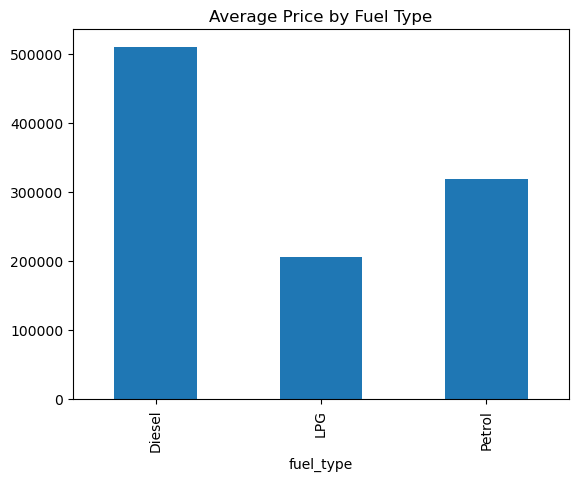

In [10]:
import matplotlib.pyplot as plt
df.groupby('fuel_type')['Price'].mean().plot(kind='bar')
plt.title('Average Price by Fuel Type')
plt.show()

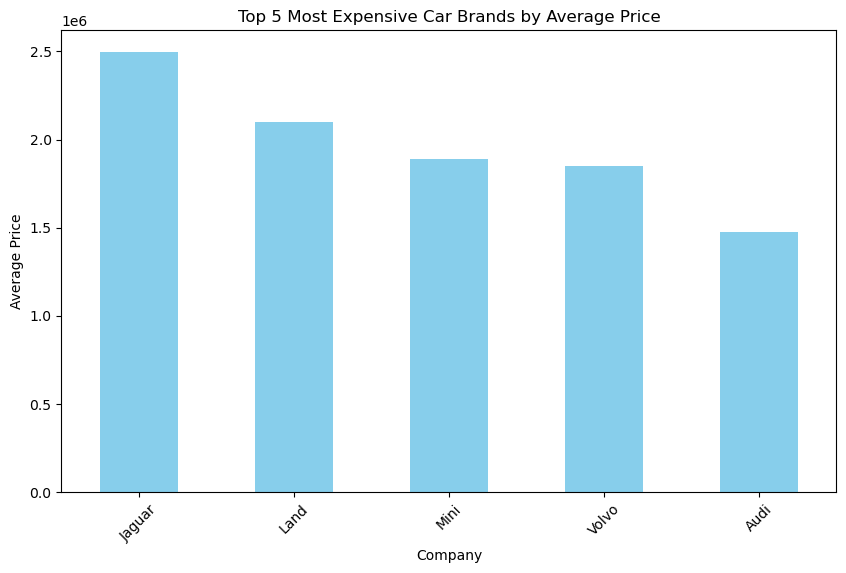

In [11]:
#Top 5 Most Expensive Brands
# Grouping and Plotting
plt.figure(figsize=(10, 6)) # It makes the chart big enough to read
df.groupby('company')['Price'].mean().sort_values(ascending=False).head(5).plot(kind='bar', color='skyblue')
plt.title('Top 5 Most Expensive Car Brands by Average Price')
plt.xlabel('Company')
plt.ylabel('Average Price')
plt.xticks(rotation=45) #This tilts the names so they don't overlap
plt.show()

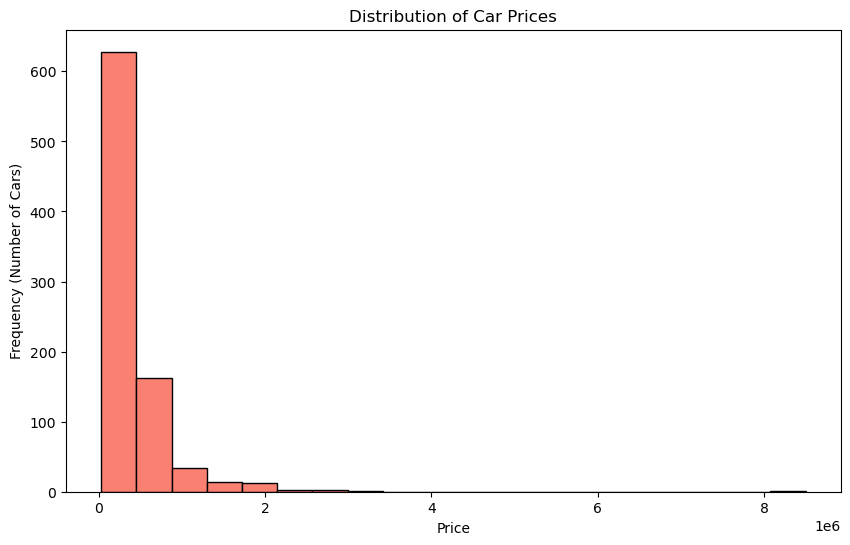

In [13]:
#2. Price Distribution (Histogram)
#This shows you the range of prices—are most cars cheap, or are there many expensive ones?
plt.figure(figsize=(10, 6))
plt.hist(df['Price'], bins=20, color='salmon', edgecolor='black')
plt.title('Distribution of Car Prices')
plt.xlabel('Price')
plt.ylabel('Frequency (Number of Cars)')
plt.show()

In [ ]:
Observation: The Price Distribution is right-skewed. The majority of the listed cars fall under the 1,000,000 price mark, indicating that the dataset primarily represents the mass-market used car segment. There are very few luxury vehicles priced above 4,000,000.

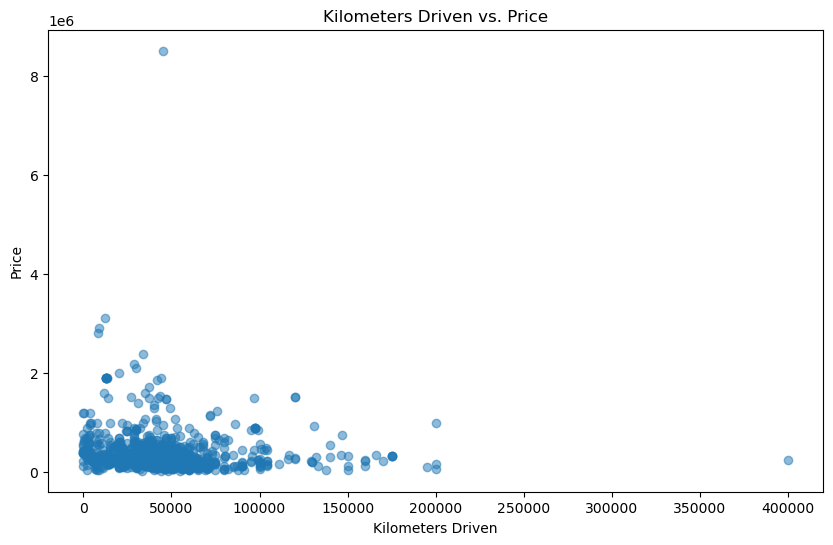

In [14]:
#Kms Driven vs. Price (Scatter Plot)
plt.figure(figsize=(10, 6))
plt.scatter(df['kms_driven'], df['Price'], alpha=0.5)
plt.title('Kilometers Driven vs. Price')
plt.xlabel('Kilometers Driven')
plt.ylabel('Price')
plt.show()

In [ ]:
Observation: The scatter plot shows a negative correlation, confirming that as mileage increases, the market price of the car decreases.